# 05 Prediction Models
After the real data are reviewed, select `water_pH`, `TDS`, or `water_temp` as target and evaluate chronological baselines and regressors.

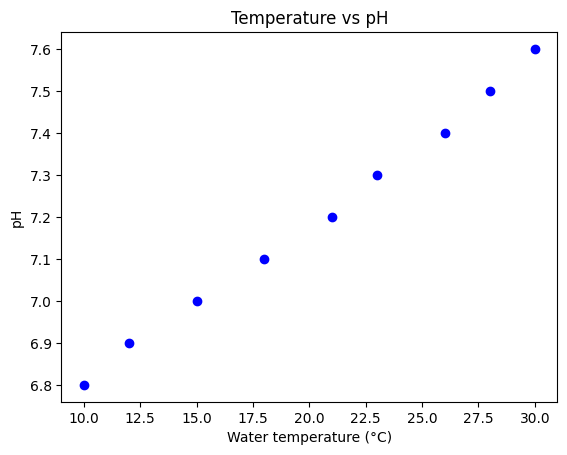

Model: pH = 0.0386 * water_temp + 6.4160
Predicted pH at 24°C: 7.34
Low-level prediction: as water temperature rises, pH tends to increase.


/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Example water-quality data
df = pd.DataFrame({
    "water_temp": [10, 12, 15, 18, 21, 23, 26, 28, 30],
    "water_pH":   [6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4, 7.5, 7.6]
})

# Plot the relationship
plt.scatter(df["water_temp"], df["water_pH"], color="blue")
plt.xlabel("Water temperature (°C)")
plt.ylabel("pH")
plt.title("Temperature vs pH")
plt.show()

# Train a simple linear model: pH = a * temp + b
X = df[["water_temp"]]
y = df["water_pH"]

model = LinearRegression()
model.fit(X, y)

# Print the trend
slope = model.coef_[0]
intercept = model.intercept_
print(f"Model: pH = {slope:.4f} * water_temp + {intercept:.4f}")

# Predict pH for a rising temperature
temp_to_predict = 24
predicted_ph = model.predict([[temp_to_predict]])[0]
print(f"Predicted pH at {temp_to_predict}°C: {predicted_ph:.2f}")

# Simple rule-style interpretation
if slope > 0:
    print("Low-level prediction: as water temperature rises, pH tends to increase.")
else:
    print("Low-level prediction: as water temperature rises, pH tends to decrease.")

In [5]:
# Load the water quality dataset
df_real = pd.read_csv(r'/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/water_quality_clean.csv')

# Display first few rows
print(df_real.head())

# Use the trained model to make predictions on the real dataset
X_real = df_real[["water_temp"]]
predictions = model.predict(X_real)

# Add predictions to the dataframe
df_real['predicted_pH'] = predictions

# Display results
print("\nPredictions on real data:")
print(df_real[["water_temp", "water_pH", "predicted_pH"]].head(10))

# Optional: Calculate prediction errors if actual pH is available
if "water_pH" in df_real.columns:
    df_real['error'] = df_real["water_pH"] - df_real['predicted_pH']
    print(f"\nMean Absolute Error: {df_real['error'].abs().mean():.4f}")

       id         created_date  water_pH  TDS  water_temp
0  181775  2023-01-26 11:24:00      7.60  250       24.00
1  181777  2023-01-26 11:33:00      7.60  247       24.06
2  181778  2023-01-26 12:02:00      7.60  249       24.19
3  181780  2023-01-26 12:05:00      6.92  247       24.19
4  181782  2023-01-26 12:10:00      7.30  245       24.25

Predictions on real data:
   water_temp  water_pH  predicted_pH
0       24.00      7.60      7.341376
1       24.06      7.60      7.343690
2       24.19      7.60      7.348702
3       24.19      6.92      7.348702
4       24.25      7.30      7.351016
5       24.25      6.96      7.351016
6       24.25      7.60      7.351016
7       24.25      6.88      7.351016
8       24.25      7.60      7.351016
9       24.25      7.19      7.351016

Mean Absolute Error: 0.4833


In [ ]:
can you give me expected pH values for temperature values ranging from 10°C to 30°C using the trained linear model?

    

In [9]:
# Expected pH values from 10°C to 30°C using the trained linear model
temps = np.arange(0, 31, 1)  # 10 through 30 inclusive
predicted_ph_values = model.predict(pd.DataFrame({"water_temp": temps}))

expected_ph_df = pd.DataFrame({
    "water_temp_C": temps,
    "expected_pH": predicted_ph_values
})

print(expected_ph_df)

output_path = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/Temp_PH_prediction.csv"
expected_ph_df.to_csv(output_path, index=False)

print(f"Datei gespeichert unter: {output_path}")



    water_temp_C  expected_pH
0              0     6.416003
1              1     6.454561
2              2     6.493118
3              3     6.531675
4              4     6.570232
5              5     6.608789
6              6     6.647347
7              7     6.685904
8              8     6.724461
9              9     6.763018
10            10     6.801575
11            11     6.840133
12            12     6.878690
13            13     6.917247
14            14     6.955804
15            15     6.994362
16            16     7.032919
17            17     7.071476
18            18     7.110033
19            19     7.148590
20            20     7.187148
21            21     7.225705
22            22     7.264262
23            23     7.302819
24            24     7.341376
25            25     7.379934
26            26     7.418491
27            27     7.457048
28            28     7.495605
29            29     7.534163
30            30     7.572720
Datei gespeichert unter: /Users/jakobsma

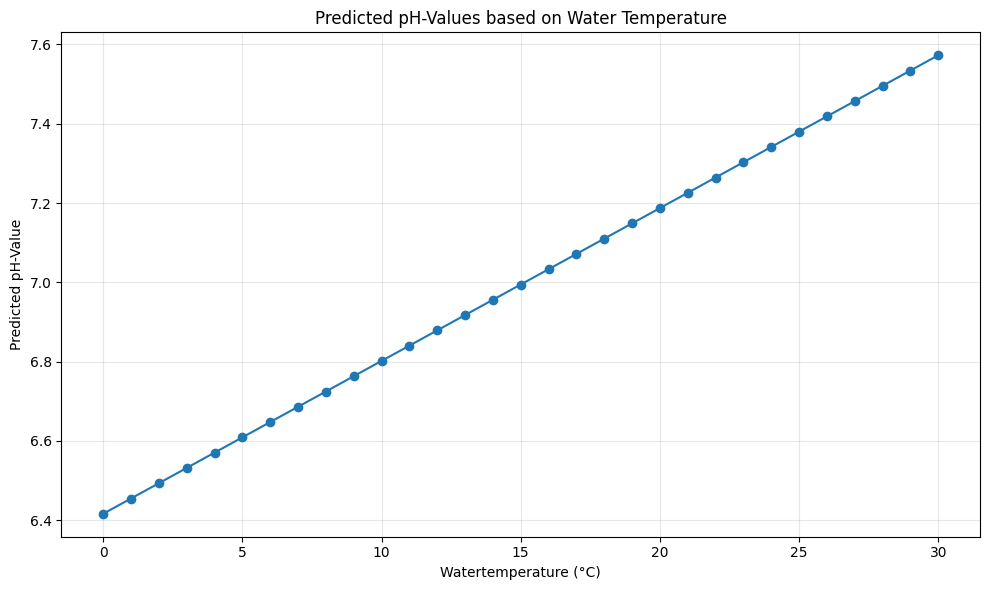

Graph gespeichert unter: /Users/jakobsmacncheese/Desktop/ISU/VRO-Project/results/figures/predictions/Temp_PH_plot.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Pfade definieren
input_path = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/Temp_PH_prediction.csv"
output_dir = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/results/figures/predictions"
os.makedirs(output_dir, exist_ok=True)

# CSV einlesen
df = pd.read_csv(input_path)

# Graph erstellen: water_temp_C vs. expected_pH
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df["water_temp_C"], df["expected_pH"], marker="o", linestyle="-", color="tab:blue")
ax.set_xlabel("Watertemperature (°C)")
ax.set_ylabel("Predicted pH-Value")
ax.set_title("Predicted pH-Values based on Water Temperature")
ax.grid(True, alpha=0.3)

fig.tight_layout()

# Speichern
output_path = os.path.join(output_dir, "Temp_PH_plot.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Graph gespeichert unter: {output_path}")

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import os

# Pfade definieren
input_path = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/water_quality_clean.csv"
output_dir = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed"
os.makedirs(output_dir, exist_ok=True)

# Daten einlesen
df = pd.read_csv(input_path)

# Optional: Zeitspalte als datetime parsen (falls später gebraucht)
df["created_date"] = pd.to_datetime(df["created_date"])

# Features und Zielgröße
X = df[["water_temp"]]
y = df["TDS"]

# Train/Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modell trainieren
model = LinearRegression()
model.fit(X_train, y_train)

# Modellgüte prüfen
y_pred_test = model.predict(X_test)
r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Koeffizient (Steigung): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Vorhersage für den gesamten Datensatz berechnen
df["expected_TDS"] = model.predict(df[["water_temp"]])

# Ergebnis als neue CSV speichern
output_path = os.path.join(output_dir, "Temp_TDS_prediction.csv")
df.to_csv(output_path, index=False)

print(f"Datei gespeichert unter: {output_path}")

R²: 0.0339
RMSE: 42.8206
Koeffizient (Steigung): -17.5937
Intercept: 769.3798
Datei gespeichert unter: /Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/Temp_TDS_prediction.csv


In [19]:
df["water_pH"].value_counts()
print(df["water_temp"].min())
print(df["water_temp"].max())


24.0
26.19


Koeffizient (Steigung): -17.6545
Intercept: 770.7064
R² (auf Trainingsdaten): 0.0333
Vorhersage-CSV gespeichert unter: /Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/TDS_prediction_0_30C.csv


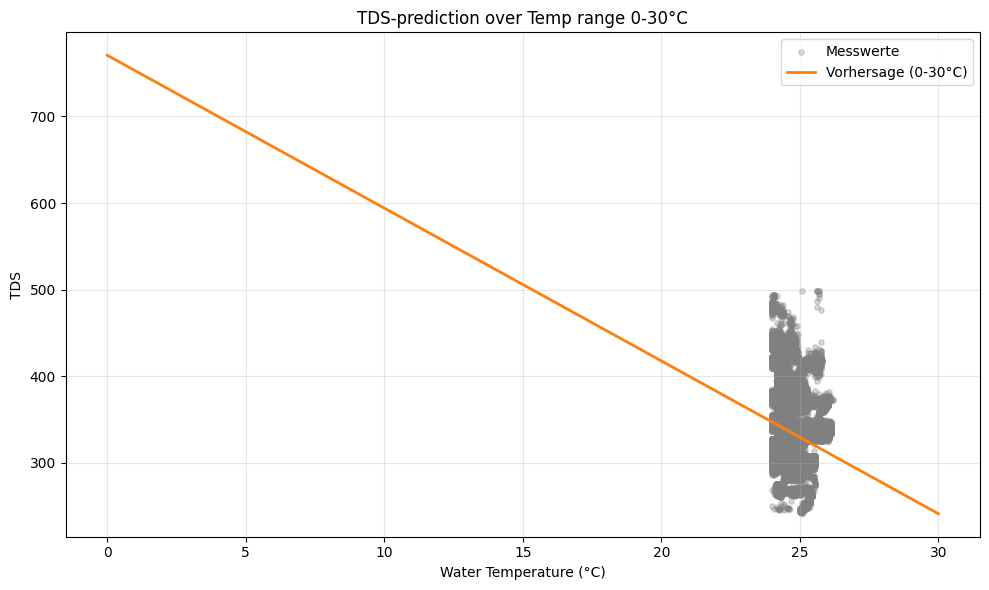

Graph gespeichert unter: /Users/jakobsmacncheese/Desktop/ISU/VRO-Project/results/figures/TDS_prediction_0_30C_Extrapoliert.png


In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import os

# Pfade definieren
input_path = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/water_quality_clean.csv"
output_dir_data = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed"
output_dir_fig = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/results/figures"
os.makedirs(output_dir_data, exist_ok=True)
os.makedirs(output_dir_fig, exist_ok=True)

# Daten einlesen
df = pd.read_csv(input_path)

# Modell auf ALLEN vorhandenen Messwerten trainieren
X = df[["water_temp"]]
y = df["TDS"]

model = LinearRegression()
model.fit(X, y)

print(f"Koeffizient (Steigung): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² (auf Trainingsdaten): {model.score(X, y):.4f}")

# Temperaturbereich 0-30 °C erzeugen (z. B. in 0.5°C-Schritten)
temp_range = np.arange(0, 30.5, 0.5)
temp_range_df = pd.DataFrame({"water_temp": temp_range})

# Vorhersage berechnen
predicted_tds = model.predict(temp_range_df)

# Ergebnis in DataFrame packen
prediction_df = pd.DataFrame({
    "water_temp": temp_range,
    "predicted_TDS": predicted_tds
})

# Als CSV speichern
output_csv_path = os.path.join(output_dir_data, "TDS_prediction_0_30C.csv")
prediction_df.to_csv(output_csv_path, index=False)
print(f"Vorhersage-CSV gespeichert unter: {output_csv_path}")

# Plot erstellen
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["water_temp"], df["TDS"], alpha=0.3, s=15, label="Messwerte", color="gray")
ax.plot(prediction_df["water_temp"], prediction_df["predicted_TDS"], color="tab:orange", linewidth=2, label="Vorhersage (0-30°C)")
ax.set_xlabel("Water Temperature (°C)")
ax.set_ylabel("TDS")
ax.set_title("TDS-prediction over Temp range 0-30°C")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

output_fig_path = os.path.join(output_dir_fig, "TDS_prediction_0_30C_Extrapoliert.png")
plt.savefig(output_fig_path, dpi=300)
plt.show()

print(f"Graph gespeichert unter: {output_fig_path}")

R²: 0.0333
Mittlerer TDS (echt): 335.42
Mittlerer TDS (vorhergesagt): 335.42
Mittleres Residuum: -0.00
Min/Max TDS (echt): 241 / 498


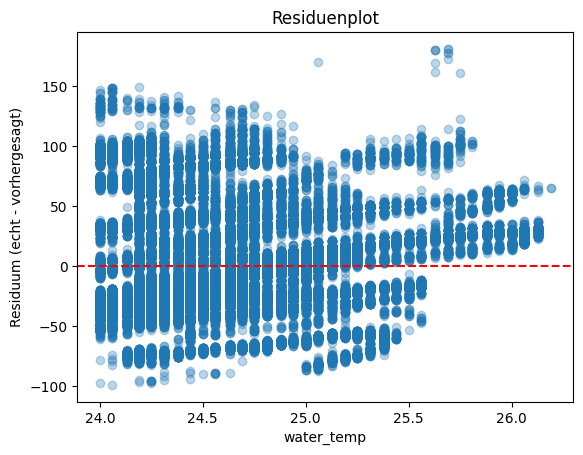

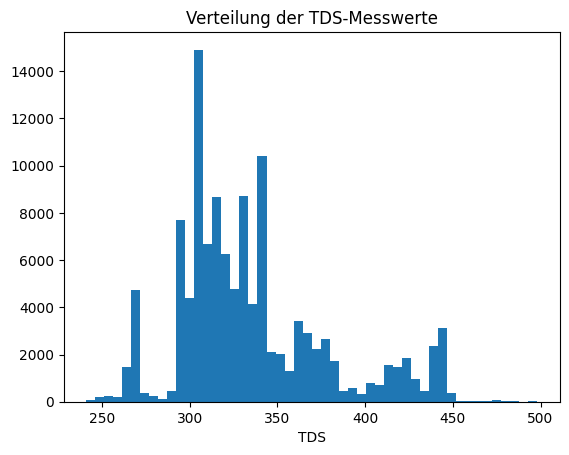

count    118286.000000
mean        335.416491
std          43.738700
min         241.000000
25%         305.000000
50%         325.000000
75%         353.000000
max         498.000000
Name: TDS, dtype: float64


In [21]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/water_quality_clean.csv")

X = df[["water_temp"]]
y = df["TDS"]

model = LinearRegression()
model.fit(X, y)

df["predicted_TDS"] = model.predict(X)
df["residual"] = df["TDS"] - df["predicted_TDS"]

print(f"R²: {model.score(X, y):.4f}")
print(f"Mittlerer TDS (echt): {y.mean():.2f}")
print(f"Mittlerer TDS (vorhergesagt): {df['predicted_TDS'].mean():.2f}")
print(f"Mittleres Residuum: {df['residual'].mean():.2f}")
print(f"Min/Max TDS (echt): {y.min()} / {y.max()}")

# Residuen-Plot: sollte um 0 streuen, nicht systematisch verschoben sein
plt.scatter(df["water_temp"], df["residual"], alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("water_temp")
plt.ylabel("Residuum (echt - vorhergesagt)")
plt.title("Residuenplot")
plt.show()

# Verteilung von TDS prüfen (Ausreißer sichtbar machen)
plt.hist(y, bins=50)
plt.xlabel("TDS")
plt.title("Verteilung der TDS-Messwerte")
plt.show()
print(df["TDS"].describe())

R²: 0.6777
Steigung: 2.7038 TDS/Tag
Intercept: 292.9060
Datei gespeichert unter: /Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/TDS_prediction_over_time.csv


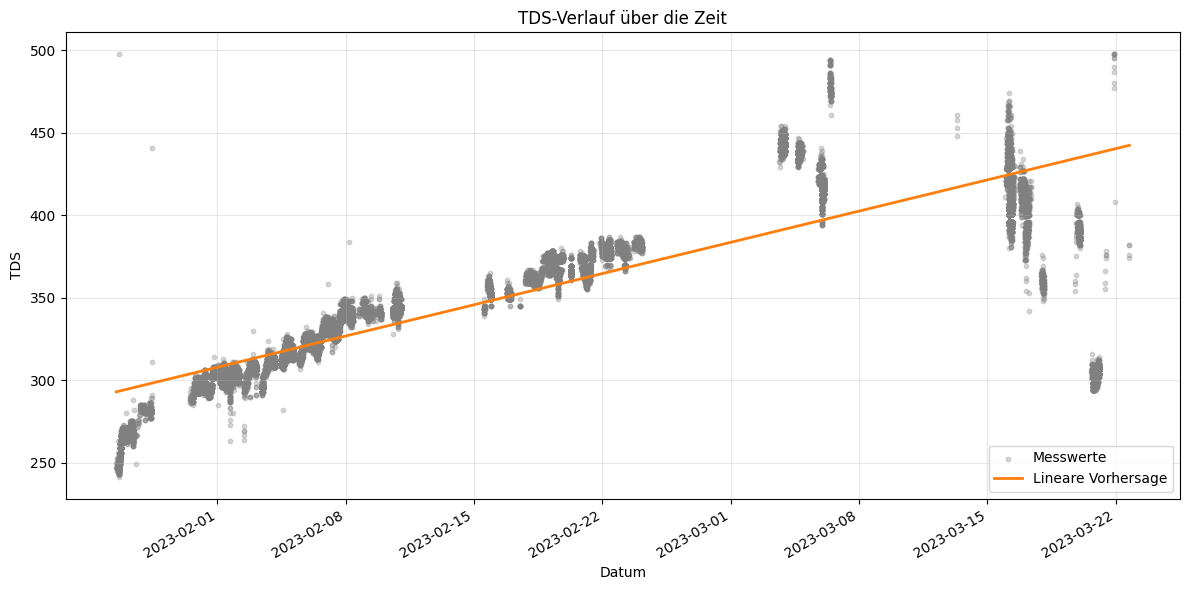

Graph gespeichert unter: /Users/jakobsmacncheese/Desktop/ISU/VRO-Project/results/figures/predictions/TDS_over_time.png


In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Pfade definieren
input_path = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/water_quality_clean.csv"
output_dir_data = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed"
output_dir_fig = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/results/figures/predictions"
os.makedirs(output_dir_data, exist_ok=True)
os.makedirs(output_dir_fig, exist_ok=True)

# Daten einlesen
df = pd.read_csv(input_path)
df["created_date"] = pd.to_datetime(df["created_date"])
df = df.sort_values("created_date").reset_index(drop=True)

# Zeit in numerisches Feature umwandeln (z. B. Sekunden/Tage seit erstem Messpunkt)
t0 = df["created_date"].min()
df["time_numeric"] = (df["created_date"] - t0).dt.total_seconds() / (3600 * 24)  # in Tagen

# Modell: TDS ~ Zeit
X = df[["time_numeric"]]
y = df["TDS"]

model = LinearRegression()
model.fit(X, y)

df["predicted_TDS"] = model.predict(X)

r2 = model.score(X, y)
print(f"R²: {r2:.4f}")
print(f"Steigung: {model.coef_[0]:.4f} TDS/Tag")
print(f"Intercept: {model.intercept_:.4f}")

# Vorhersage-CSV speichern
output_csv_path = os.path.join(output_dir_data, "TDS_prediction_over_time.csv")
df[["created_date", "TDS", "predicted_TDS"]].to_csv(output_csv_path, index=False)
print(f"Datei gespeichert unter: {output_csv_path}")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df["created_date"], df["TDS"], alpha=0.3, s=10, color="gray", label="Messwerte")
ax.plot(df["created_date"], df["predicted_TDS"], color="tab:orange", linewidth=2, label="Lineare Vorhersage")

ax.set_xlabel("Datum")
ax.set_ylabel("TDS")
ax.set_title("TDS-Verlauf über die Zeit")
ax.legend()
ax.grid(True, alpha=0.3)

# Datumsachse schön formatieren
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()

fig.tight_layout()
output_fig_path = os.path.join(output_dir_fig, "TDS_over_time.png")
plt.savefig(output_fig_path, dpi=300)
plt.show()

print(f"Graph gespeichert unter: {output_fig_path}")

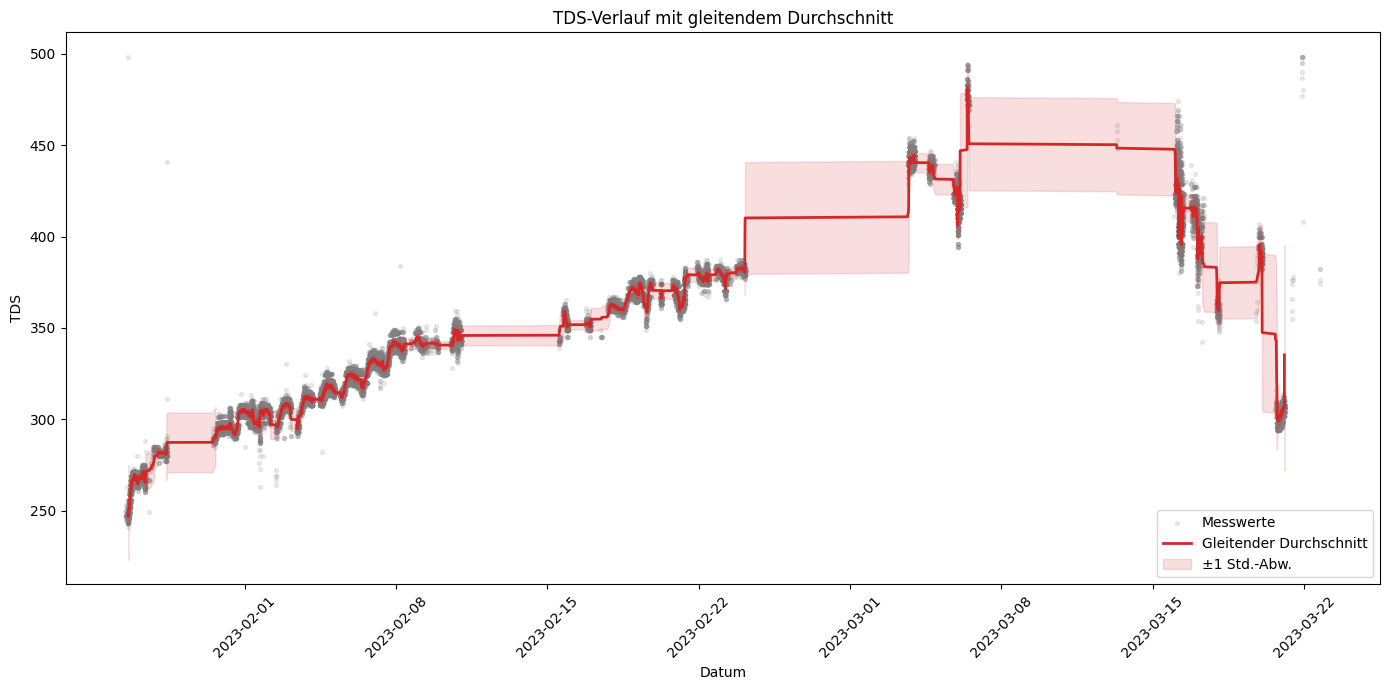

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Gleitender Durchschnitt für den Grundtrend
df["TDS_rolling_mean"] = df["TDS"].rolling(window=100, center=True).mean()
df["TDS_rolling_std"] = df["TDS"].rolling(window=100, center=True).std()

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(df["created_date"], df["TDS"], alpha=0.15, s=8, color="gray", label="Messwerte")
ax.plot(df["created_date"], df["TDS_rolling_mean"], color="tab:red", linewidth=2, label="Gleitender Durchschnitt")
ax.fill_between(df["created_date"],
                 df["TDS_rolling_mean"] - df["TDS_rolling_std"],
                 df["TDS_rolling_mean"] + df["TDS_rolling_std"],
                 color="tab:red", alpha=0.15, label="±1 Std.-Abw.")
ax.set_xlabel("Datum")
ax.set_ylabel("TDS")
ax.set_title("TDS-Verlauf mit gleitendem Durchschnitt")
ax.legend()
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

In [80]:
# prep for non linear model for TDS prediction based on water temperature

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit

# --- Daten vorbereiten TDS ---
data = df[["water_temp", "TDS"]].dropna()
X = data[["water_temp"]].values
y = data["TDS"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Wichtig: T_range hier definieren, damit alle Optionen es nutzen können
T_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

In [81]:
#Random Forest approach for TDS prediction based on water temperature

rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"[Random Forest] R²: {r2_score(y_test, y_pred_rf):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")

TDS_pred_rf = rf.predict(T_range)

[Random Forest] R²: 0.114, RMSE: 40.984


In [82]:
# polynomial regression approach for TDS prediction based on water temperature 3 grade

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit

degree = 2
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)
print(f"[Polynom] R²: {r2_score(y_test, y_pred_poly):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.3f}")

T_range_poly = poly.transform(T_range)
TDS_pred_poly = poly_model.predict(T_range_poly)

[Polynom] R²: 0.083, RMSE: 41.683


In [83]:
# exponential curve fitting approach for TDS prediction based on water temperature

def model_func(T, a, b, c):
    return a * np.exp(b * T) + c

try:
    params, _ = curve_fit(model_func, X.flatten(), y, p0=[1, 0.01, 1], maxfev=10000)
    TDS_pred_exp = model_func(T_range.flatten(), *params)
    has_exp = True
except RuntimeError:
    print("Exponentieller Fit konnte nicht konvergieren.")
    has_exp = False


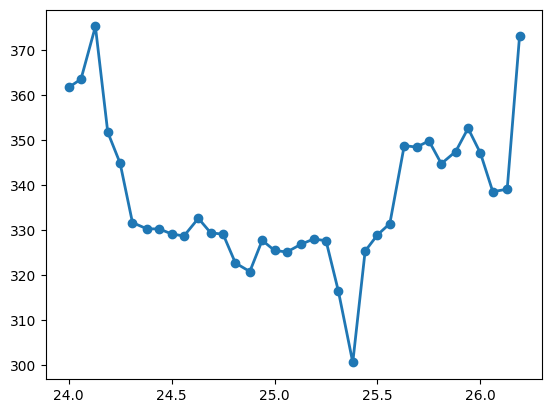

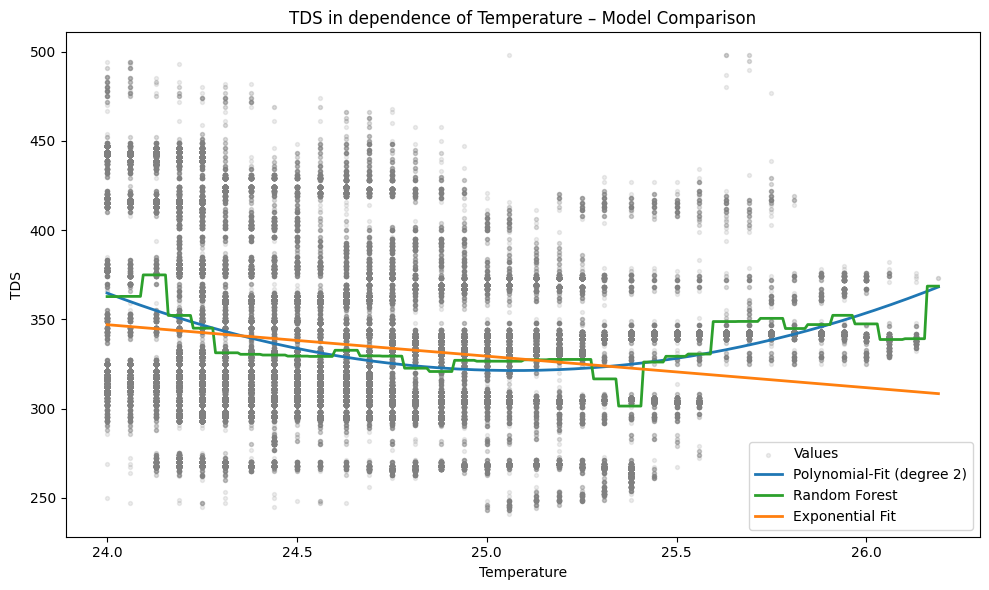

In [88]:
# Plotting the predictions
tds_mean = df.groupby("water_temp")["TDS"].mean().reset_index()

plt.plot(
    tds_mean["water_temp"],
    tds_mean["TDS"],
    marker="o",
    linewidth=2,
    label="Ø TDS je Temperatur"
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y, alpha=0.15, s=8, color="gray", label="Values")
ax.plot(T_range, TDS_pred_poly, color="tab:blue", linewidth=2, label=f"Polynomial-Fit (degree {degree})")
ax.plot(T_range, TDS_pred_rf, color="tab:green", linewidth=2, label="Random Forest")



if has_exp:
    ax.plot(T_range, TDS_pred_exp, color="tab:orange", linewidth=2, label="Exponential Fit")
ax.set_xlabel("Temperature")
ax.set_ylabel("TDS")
ax.set_title("TDS in dependence of Temperature – Model Comparison")
ax.legend()
fig.tight_layout()


output_fig_path = os.path.join("/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/results/figures/predictions", "TDS_prediction_models_comparison.png")
plt.savefig(output_fig_path, dpi=300)

plt.show()

[Polynom] R²: 0.008, RMSE: 0.555
[Random Forest] R²: 0.015, RMSE: 0.553


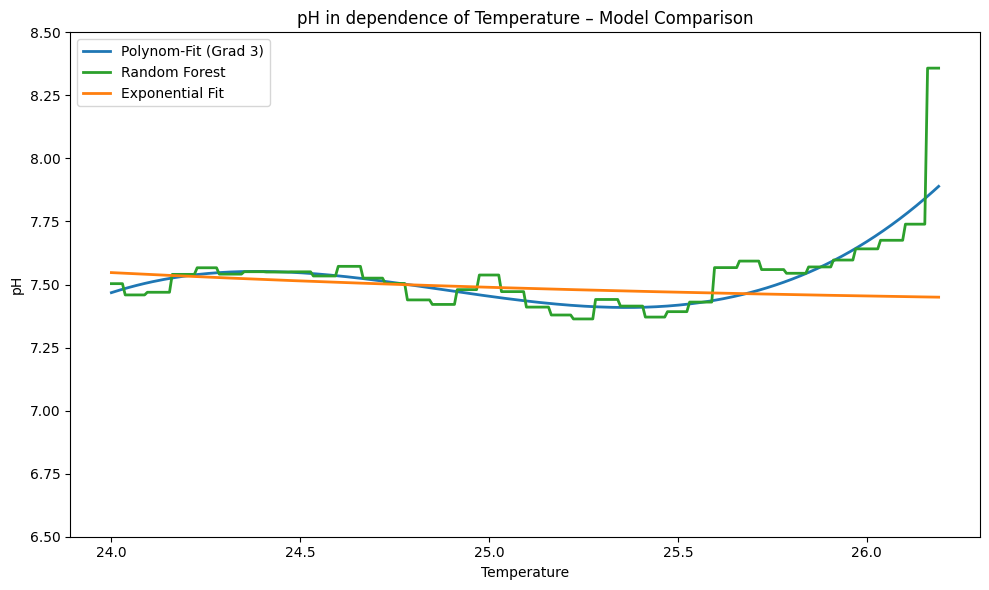


=== Modellvergleich (Testdaten) ===
                      R²    RMSE
Random Forest     0.0146  0.5528
Polynom (Grad 3)  0.0081  0.5546
Exponentiell      0.0020  0.5563


In [71]:
# same aprroach for pH prediction based on water temperature

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit

# --- Daten vorbereiten ---
data = df[["water_temp", "water_pH"]].dropna()
X = data[["water_temp"]].values
y = data["water_pH"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# T_range für alle Modelle
T_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

# --- Option 1: Polynomiale Regression ---
degree = 3
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)
print(f"[Polynom] R²: {r2_score(y_test, y_pred_poly):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.3f}")

T_range_poly = poly.transform(T_range)
TDS_pred_poly = poly_model.predict(T_range_poly)

# --- Option 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"[Random Forest] R²: {r2_score(y_test, y_pred_rf):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")

TDS_pred_rf = rf.predict(T_range)

# --- Option 3: Exponentieller Fit (optional) ---
def model_func(T, a, b, c):
    return a * np.exp(b * T) + c

has_exp = False

try:
    params, _ = curve_fit(model_func, X.flatten(), y, p0=[1, 0.01, 1], maxfev=10000)
    TDS_pred_exp = model_func(T_range.flatten(), *params)
    has_exp = True
except Exception as e:
    print(f"Exponentieller Fit konnte nicht durchgeführt werden: {e}")

# --- Plot aller Modelle zusammen ---
fig, ax = plt.subplots(figsize=(10, 6))
#ax.scatter(X, y, alpha=0.15, s=8, color="gray", label="Messwerte")
ax.plot(T_range, TDS_pred_poly, color="tab:blue", linewidth=2, label=f"Polynom-Fit (Grad {degree})")
ax.plot(T_range, TDS_pred_rf, color="tab:green", linewidth=2, label="Random Forest")
if has_exp:
    ax.plot(T_range, TDS_pred_exp, color="tab:orange", linewidth=2, label="Exponential Fit")
    ax.set_ylim(6.5, 8.5)  # Optional: Set limits for better visualization

ax.set_xlabel("Temperature")
ax.set_ylabel("pH")
ax.set_title("pH in dependence of Temperature – Model Comparison")
ax.legend()
fig.tight_layout()

output_fig_path = os.path.join(output_dir_fig, "pH_prediction_models_comparison.png")
plt.savefig(output_fig_path, dpi=300)

plt.show()

import pandas as pd

# --- Vergleichstabelle der Modelle ---
results = {
    "Polynom (Grad 3)": {
        "R²": r2_score(y_test, y_pred_poly),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_poly))
    },
    "Random Forest": {
        "R²": r2_score(y_test, y_pred_rf),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf))
    }
}

if has_exp:
    # Test-Vorhersage für exponentiellen Fit berechnen
    y_pred_exp_test = model_func(X_test.flatten(), *params)
    results["Exponentiell"] = {
        "R²": r2_score(y_test, y_pred_exp_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_exp_test))
    }

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("R²", ascending=False)

print("\n=== Modellvergleich (Testdaten) ===")
print(results_df.round(4))

[Polynom] R²: 0.017, RMSE: 0.552
[Random Forest] R²: 0.178, RMSE: 0.505


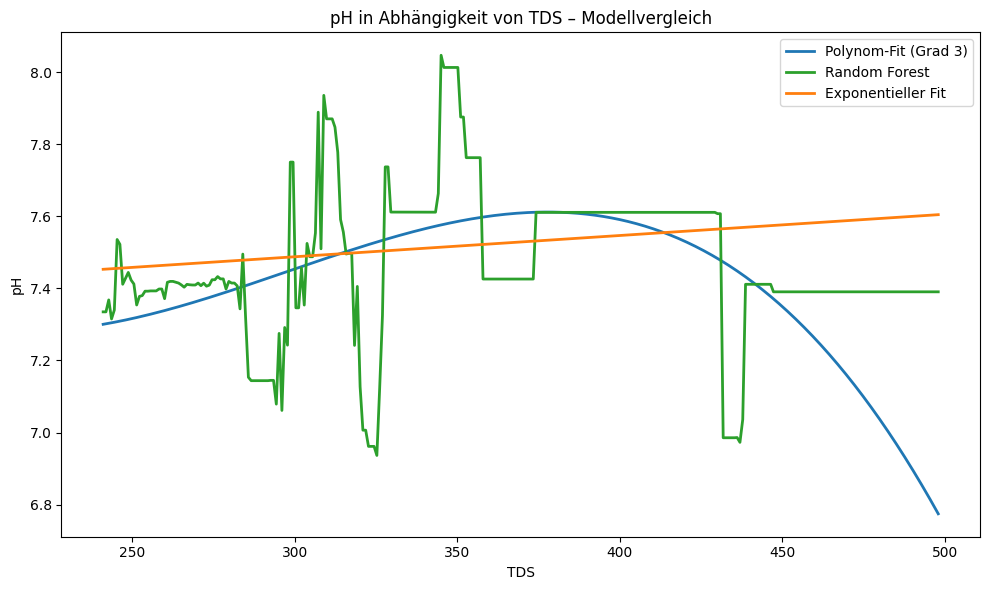

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit

# --- Daten vorbereiten ---
data = df[["TDS", "water_pH"]].dropna()
X = data[["TDS"]].values
y = data["water_pH"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Wichtig: Range für Vorhersagekurve definieren
TDS_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

# --- Option 1: Polynomiale Regression ---
degree = 3
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)
print(f"[Polynom] R²: {r2_score(y_test, y_pred_poly):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.3f}")

TDS_range_poly = poly.transform(TDS_range)
pH_pred_poly = poly_model.predict(TDS_range_poly)

# --- Option 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"[Random Forest] R²: {r2_score(y_test, y_pred_rf):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")

pH_pred_rf = rf.predict(TDS_range)

# --- Option 3: Exponentieller Fit (optional) ---
def model_func(TDS, a, b, c):
    return a * np.exp(b * TDS) + c

has_exp = False

try:
    params, _ = curve_fit(model_func, X.flatten(), y, p0=[1, 0.0001, y.mean()], maxfev=10000)
    pH_pred_exp = model_func(TDS_range.flatten(), *params)
    has_exp = True
except Exception as e:
    print(f"Exponentieller Fit konnte nicht durchgeführt werden: {e}")

# --- Plot aller Modelle zusammen ---
fig, ax = plt.subplots(figsize=(10, 6))
#ax.scatter(X, y, alpha=0.15, s=8, color="gray", label="Messwerte")
ax.plot(TDS_range, pH_pred_poly, color="tab:blue", linewidth=2, label=f"Polynom-Fit (Grad {degree})")
ax.plot(TDS_range, pH_pred_rf, color="tab:green", linewidth=2, label="Random Forest")
if has_exp:
    ax.plot(TDS_range, pH_pred_exp, color="tab:orange", linewidth=2, label="Exponentieller Fit")
ax.set_xlabel("TDS")
ax.set_ylabel("pH")
ax.set_title("pH in Abhängigkeit von TDS – Modellvergleich")
ax.legend()
fig.tight_layout()
plt.show()